## 1. Data
Run once; rerun from Settings when changing strategies.

In [23]:
from io import StringIO
import pandas as pd
import matplotlib.pyplot as plt
from crypto_trader.data import fetch_hourly

data = fetch_hourly(period="1y")
frames = {s: pd.read_json(StringIO(raw), orient="table") for s, raw in data.items()}

In [24]:
frames.keys()

dict_keys(['BTC-USD', 'ETH-USD', 'SOL-USD', 'HYPE32196-USD', 'DOGE-USD'])

## 2. Settings
Tune on train; reserve the final three months for testing.

In [35]:
symbol = "BTC-USD"
sample = "train"  # "train", "test", or "all".
fee = 0.000      # Assumed fee per traded dollar; no slippage.
prices = frames[symbol].sort_index().copy()

## 3. Strategy functions
Return a Series on the price index: 0 = cash, 0.5 = half invested, 1 = fully invested. Return NaN during warm-up. Use only current and earlier prices. Do not shift weights here; the backtest does that.

In [36]:
def mean_reversion(prices, window=48, strength=2):
    close = prices["Close"]
    average = close.rolling(window).mean()
    spread = close.rolling(window).std()

    z_score = (close - average) / spread.replace(0, float("nan"))
    return (-z_score / strength).clip(-1, 1)


def mean_reversion_threshold(prices, window=48, entry=1, full=2):
    close = prices["Close"]
    average = close.rolling(window).mean()
    spread = close.rolling(window).std()
    z = (close - average) / spread.replace(0, float("nan"))

    # Stay in cash inside the threshold; scale up beyond it.
    size = ((z.abs() - entry) / (full - entry)).clip(0, 1)
    direction = -z / z.abs().replace(0, 1)
    return direction * size

## 4. Choose strategies
Add an entry and its parameters here. Strategies share the same evaluation dates after warm-up.

In [37]:
strategies = {
    "Mean Reversion": mean_reversion(prices, window=48, strength=2),
    "Mean Reversion Threshold": mean_reversion_threshold(prices, window=48, entry=1, full=2),
    "Buy and hold": pd.Series(1.0, index=prices.index),

}
for name, weights in strategies.items():
    assert isinstance(weights, pd.Series) and weights.index.equals(prices.index), name
    assert weights.dropna().between(-1, 1).all(), f"{name}: weights must be -1 to 1"
positions = pd.DataFrame(strategies)

## 5. Shared backtest
Leave this unchanged when adding strategies. Assumes execution at the signal close. Fees approximate changes in target weights, ignoring weight drift and slippage. Each sample starts in cash with an entry fee; no forced exit.

In [38]:
market_returns = prices["Close"].pct_change()
held = positions.shift(1)  # Previous weight earns the next return.
split = prices.index.max() - pd.DateOffset(months=3)
periods = {"train": prices.index < split, "test": prices.index >= split,
           "all": pd.Series(True, index=prices.index)}
selected = held.notna().all(axis=1) & market_returns.notna() & periods[sample]
held = held.loc[selected]
if held.empty:
    raise ValueError("No rows to test: check the sample and warm-up windows.")
turnover = held.diff().abs()
turnover.iloc[0] = held.iloc[0].abs()  # Initial purchase from cash.
strategy_returns = held.mul(market_returns.loc[selected], axis=0) - fee * turnover
equity = (1 + strategy_returns).cumprod()
# Include the starting $1 before the first scored return.
start = prices.index[prices.index.get_loc(equity.index[0]) - 1]
equity = pd.concat([pd.DataFrame(1.0, index=[start], columns=equity.columns), equity])

## 6. Results
After changing a rule or parameter, rerun Settings and every cell below it.

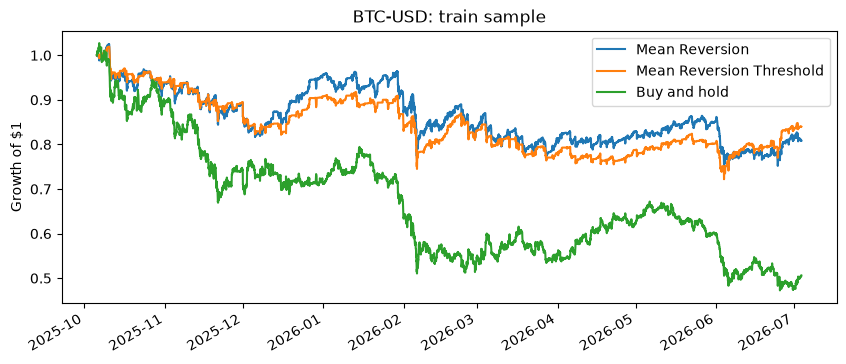

,Total return,Max drawdown,Sharpe ratio
Mean Reversion,-0.191694,0.271110,-0.746826
Mean Reversion Threshold,-0.160106,0.291705,-0.752981
Buy and hold,-0.494030,0.539944,-1.741757


In [39]:
equity.plot(figsize=(10, 4), title=f"{symbol}: {sample} sample", ylabel="Growth of $1")
plt.show()
summary = pd.DataFrame({
    "Total return": equity.iloc[-1] - 1,
    "Max drawdown": (1 - equity / equity.cummax()).max(),
    "Sharpe ratio": strategy_returns.mean() / strategy_returns.std() * (365 * 24) ** 0.5,
})
summary